# Lab 06 — Evaluation: the embedder bake-off

Up to now we judged retrieval by eye. This lab puts **numbers** on it, on the
*real* RAM papers, using:
- a hand-labelled eval set — `eval_set.py`: 15 questions → the paper that answers each,
- real metrics — `metrics.py`: recall@k, MRR, nDCG,
- the ingestion pipeline (`ingestion/ram_rag.py`) to chunk + embed + retrieve.

Everything embeds on the **GPU** via `--model tei` — nothing downloads locally.

**Before running:** `./tunnel.sh` (Postgres + TEI), and TEI must be serving a model.
To compare models, swap TEI's `--model-id` between runs (see the last cell).

In [1]:
%matplotlib inline
import sys, json
from pathlib import Path
p = Path.cwd()
LABS = next(d for d in [p, *p.parents] if (d / "shared").exists())
for sub in (str(LABS), str(LABS / "ingestion"), str(LABS / "06_evaluation")):
    if sub not in sys.path:
        sys.path.insert(0, sub)
import bakeoff, ram_rag, metrics as M
from eval_set import EVAL
from shared.embedder import get_embedder
RESULTS = LABS / "06_evaluation" / "results.json"
print(len(EVAL), "labelled questions over", len({g for _, g in EVAL}), "papers")

15 labelled questions over 10 papers


## 1. The eval set and the metrics
Gold is *paper-level*: each question has exactly one paper that answers it, so a
retriever is right if it ranks that paper's chunks at the top.

In [2]:
for q, gold in EVAL[:4]:
    print(f"• {q}\n    → {gold}")
# metric sanity: gold at rank 2 of [a,b,c]
print("\nmetrics demo:", {k: round(v, 3) for k, v in
      M.aggregate([(["a", "b", "c"], "b")], ks=(1, 3, 5)).items()})

• Which hormones cross-talk to regulate the root apical meristem?
    → 10.1007@s11103-008-9393-6
• How does abscisic acid interact with auxin and cytokinin at the root meristem?
    → 10.1007@s11103-008-9393-6
• How does CLAVATA3/CLE peptide signaling regulate the shoot and root meristem?
    → miwa2008
• What allelopathic effect do volatile monoterpenoids from Salvia leucophylla have on the root meristem?
    → nishida2005

metrics demo: {'recall@1': 0.0, 'recall@3': 1.0, 'recall@5': 1.0, 'mrr': 0.5, 'ndcg@5': 0.631}


## 2. Score the model TEI is serving right now
This ingests the papers with the current embedder, retrieves for each question,
and aggregates. It also appends to `results.json` for the comparison below.

In [3]:
bakeoff.run("tei", k=5)   # ingest + score + save

model: tei:Qwen/Qwen3-Embedding-0.6B (1024d)


457 chunks (clean=True); embedding with tei:Qwen/Qwen3-Embedding-0.6B (1024d)...


ingested 457 chunks; scoring 15 labelled questions...


  recall@1=0.867  recall@3=1.000  recall@5=1.000  mrr=0.922  ndcg@5=0.942
✓ saved. Run more models, then: bakeoff.py report


### Per-question breakdown
Where did the *correct* paper land for each question? (`✓` = ranked first.)

In [4]:
emb = get_embedder("tei")
for q, gold in EVAL:
    papers = bakeoff.ranked_papers(emb, q, 10)
    r = papers.index(gold) + 1 if gold in papers else None
    mark = "✓" if r == 1 else (f"#{r}" if r else "MISS")
    print(f"{mark:>4}  {q[:58]:<58}  gold={gold[:20]}")

   ✓  Which hormones cross-talk to regulate the root apical meri  gold=10.1007@s11103-008-9


   ✓  How does abscisic acid interact with auxin and cytokinin a  gold=10.1007@s11103-008-9


  #3  How does CLAVATA3/CLE peptide signaling regulate the shoot  gold=miwa2008


   ✓  What allelopathic effect do volatile monoterpenoids from S  gold=nishida2005


   ✓  Which monoterpenoid compounds inhibit DNA synthesis and ce  gold=nishida2005


...

   ✓  How do reactive oxygen species connect root development to  gold=detullio2010


  #2  What is the role of the quiescent center in root apical me  gold=jiang2005


   ✓  How do cytokinin and auxin treatments affect terpenoid bio  gold=danova2017


   ✓  How is the balance between cell division and differentiati  gold=perilli2012


   ✓  How is epigenetic regulation involved in shoot apical meri  gold=nguyen2022


## 3. Compare models
As you score more models (swap TEI, re-run cell 2), this plot fills in. Bars are
recall@1 / recall@3 / MRR — higher is better.

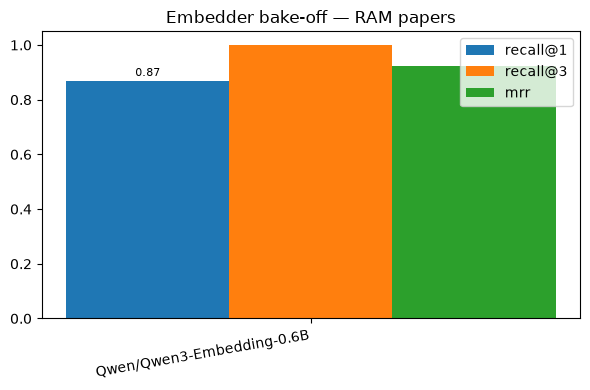

scored so far: Qwen/Qwen3-Embedding-0.6B


In [5]:
import numpy as np, matplotlib.pyplot as plt
data = json.loads(RESULTS.read_text())
models = list(data)
mets = ["recall@1", "recall@3", "mrr"]
x = np.arange(len(models)); w = 0.25
fig, ax = plt.subplots(figsize=(max(6, 2.2 * len(models)), 4))
for i, m in enumerate(mets):
    ax.bar(x + (i - 1) * w, [data[k][m] for k in models], w, label=m)
ax.set_xticks(x)
ax.set_xticklabels([k.replace("tei:", "") for k in models], rotation=10, ha="right")
ax.set_ylim(0, 1.05); ax.set_title("Embedder bake-off — RAM papers"); ax.legend()
for i, k in enumerate(models):
    ax.text(i - w, data[k]["recall@1"] + 0.02, f"{data[k]['recall@1']:.2f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()
print("scored so far:", ", ".join(k.replace("tei:", "") for k in models))

## Add another model (the swap workflow)
TEI serves one model per container, so to add a candidate, recreate it on the GPU
(downloads there, not locally), then re-run cell 2 and the plot:

```bash
ssh -t rtx5090 'sudo docker rm -f tei-embed && sudo docker run -d --name tei-embed \
  --restart unless-stopped --gpus all -p 127.0.0.1:8085:80 -v /home/ai-server/tei-data:/data \
  ghcr.io/huggingface/text-embeddings-inference:120-1.9 --model-id BAAI/bge-m3'
```

Candidates verified TEI-compatible (self-hosted, 1024-dim): `Qwen/Qwen3-Embedding-0.6B`,
`BAAI/bge-m3`. **The point of the lab:** the leaderboard is a shortlist — this table,
on *your* corpus, is the answer.